In [60]:
import surfradpy.database as srfdb

# Setting

In [61]:
prefix = '/Volumes'
version = '0.1' #this is wehere the langleys go
version_in = '0.2'
"""
changes
-------
0.1 - as PMOD-FRC 2025
"""

'\nchanges\n-------\n0.1 - as PMOD-FRC 2025\n'

In [62]:
site = 'inl'

In [63]:
p2ft = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosine_corrected/v0.2/2026/inl_mfrsr_cosinecorrected_20260415.nc')

In [64]:
p2f_in = f'{prefix}/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v{version_in}/'
# output is no longer neaded if we save parameters in database
# p2fld_lang = f'{prefix}/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}'


# Make workplan

* database workplan!
* check if next day is needed, is there afunction for that these days?

In [65]:
import productomator.worker as prowo

In [66]:
reload(prowo)

<module 'productomator.worker' from '/Users/htelg/prog/productomator/productomator/worker.py'>

In [67]:
lambda p2ft: pd.to_datetime(p2ft.name.split('_')[-1].strip('.nc'))

<function __main__.<lambda>(p2ft)>

In [68]:
wp = prowo.Workplanner(
    p2fld_in = p2f_in,
    p2fld_out=None,
    database=(srfdb.get_default_db_path(), 'mfrsr_calibration_parameters', 'timestamp', 'input_file'),
    date_from_name=lambda name: pd.to_datetime(name.split('_')[-1].strip('.nc')),
    output_file_format=None,
    glob_pattern_in='*.nc',
    start=None,
    end=None,
    input_directory_structure='yearly',
    output_directory_structure=None,
    file_complete_check=False,
    reporter=None,
    verbose=True,
    # **kwargs,
)

start time: 2026-08-26 15:07:32.321534


In [69]:
self = wp

In [70]:
wp.masterplan

Get all files in /Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosine_corrected/v0.2 with glob pattern: *.nc


,p2f_in,in_database
2026-04-15,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-16,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-17,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-18,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-19,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
...,...,...
2026-08-22,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-08-23,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-08-24,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-08-25,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None


In [198]:
wp.workplan.iloc[0].p2f_in

PosixPath('/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosine_corrected/v0.2/2026/inl_mfrsr_cosinecorrected_20260415.nc')

## process single row

In [72]:
# %matplotlib inline

-15


/Users/htelg/prog/productomator/productomator/worker.py:383: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_wholeday = xr.concat(dslist, dim = 'datetime')


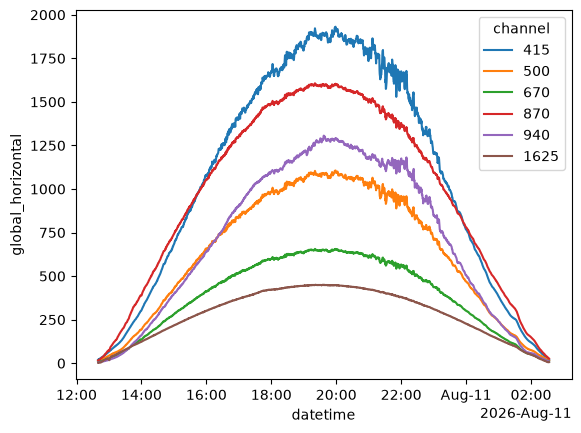

In [137]:
# i = 0
i = -15
# i = 76
# i = 57
# i = 52
# i = 46
# i = 29 #29,16,15
# i = 16
# i = 15
# i += 1
# i -=1

print(i)
row = wp.workplan.iloc[i] 

out = self.open_local_day(row, lambda x: xr.open_dataset(x), cut_nighttime=True)

# out = open_local_day(row)

ds = out['dataset']

ds.global_horizontal.plot.line(x = 'datetime')


In [138]:
# fn = '/Volumes/grad/surfrad/scaled/inl/2026/gradobs-scaled.inl.20260806.dat'
# df = pd.read_csv(fn)
# df
# # df['Global1[mV]'].plot()
# df['Diffuse[mV]'].plot()

In [139]:
out = {}

In [140]:
ds = ds.drop_vars(['solar_azimuth_angle', 'solar_zenith_angle']) # we will need to recalculate to get more solar positions anyway.

In [141]:
import atmPy.radiation.retrievals.spectral_irradiance as atmspec

In [142]:
reload(atmspec)
reload(atmspec.atmlangcalib)

<module 'atmPy.radiation.retrievals.langley_calibration' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py'>

In [143]:
si = atmspec.CombinedGlobalDiffuseDirect(ds.copy())

In [144]:
sir = si.direct_normal_irradiation

In [145]:
sir.sun_position

<xarray.Dataset> Size: 203kB
Dimensions:              (datetime: 2541)
Coordinates:
  * datetime             (datetime) datetime64[ns] 20kB 2026-08-10T12:33:20 ....
Data variables:
    zenith               (datetime) float64 20kB 1.571 1.57 1.569 ... 1.57 1.571
    zenith_geometric     (datetime) float64 20kB 1.579 1.578 ... 1.578 1.579
    elevation_geometric  (datetime) float64 20kB -0.00789 ... -0.007837
    elevation            (datetime) float64 20kB 0.0001444 ... 0.0001903
    azimuth              (datetime) float64 20kB 1.186 1.187 ... 5.092 5.093
    equation_of_time     (datetime) float64 20kB -5.374 -5.374 ... -5.283 -5.283
    airmass              (datetime) float64 20kB 37.8 37.09 36.4 ... 37.05 37.76
    airmass_absolute     (datetime) float64 20kB 31.56 30.96 ... 30.93 31.52
    sun_earth_distance   (datetime) float64 20kB 1.014 1.014 ... 1.014 1.014
Attributes: (12/27)
    instrument:                 mfrsr
    start_time:                 2026-08-09 18:30:00
    avg_period:                 20
    sample_rate:                20
    logger_id:                  $BF4F
    head_id:                    $97A4
    ...                         ...
    calibrated_spectral:        True
    clalibration_cosine:        True
    processing_class:           surfradpy.products.mfrsr_cosinecorrection.Cal...
    calibration_file_cosine:    /nfs/grad/Calibration_facilities/cucf/NOAA_GR...
    calibration_file_spectral:  /nfs/grad/Calibration_facilities/cucf/NOAA_GR...
    version:                    0.2

## get the langleys

In [181]:
langley_airmass_limits = (2, 6)
sir.settings_langley_airmass_limits = langley_airmass_limits

In [182]:
clean = 'normal'
if not clean:
    # print('no clean')
    out['langley_am'] = sir.langley_am
    out['langley_pm'] = sir.langley_pm
elif clean == 'normal':
    lang = sir.langley_am
    
    # lang.plot(wavelength=None, show_pre_clean=False)
    # clean the langley
    th = 2
    lc = lang.clean(threshold=th)
    langc_am = lc['langley']
    
    lang = sir.langley_pm
    lc = lang.clean(threshold=th)
    langc_pm = lc['langley']
    
    out['langley_am'] = langc_am
    out['langley_pm'] = langc_pm

skewness: -0.1174	 skewscale:2.4697
skewness: 0.2080	 skewscale:2.8318
skewness: 0.2112	 skewscale:2.8449
skewness: 0.2142	 skewscale:2.8568
skewness: 0.2107	 skewscale:2.8427


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py:894: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  langley.langleys = langley.langleys[where]
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py:894: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  langley.langleys = langley.langleys[where]
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py:894: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  langley.langleys = langley.langleys[where]


In [183]:
(np.exp(langc_am.langley_fitres.intercept) - np.exp(langc_pm.langley_fitres.intercept)) / np.exp(langc_am.langley_fitres.intercept)

wavelength
415    -0.031032
500    -0.018433
670    -0.013631
870    -0.010706
940    -0.082380
1625   -0.012238
Name: intercept, dtype: float64

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

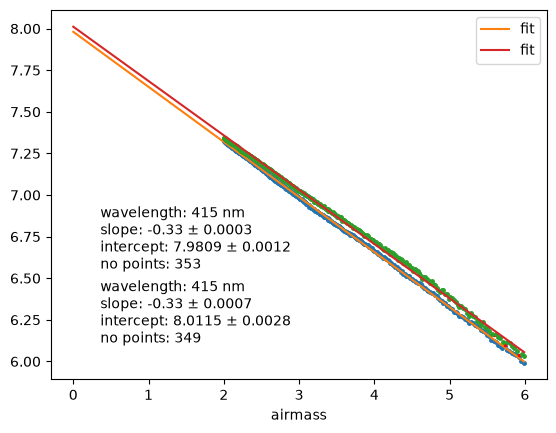

In [184]:
txtpos = [0.1, 0.3]

wl = 415
f,a = plt.subplots()
langc_am.plot(wavelength=wl, textpos=txtpos , ax = a)
langc_pm.plot(wavelength= wl, ax = a)


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

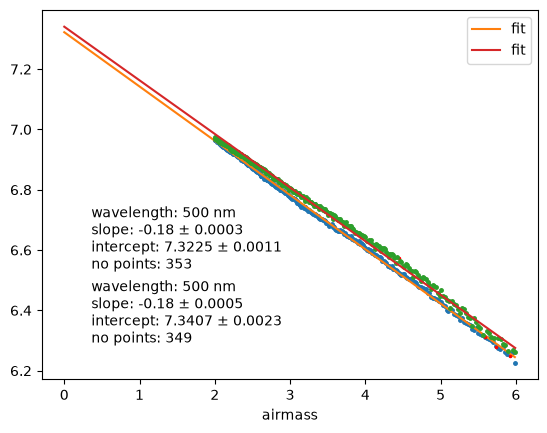

In [185]:
wl = 500
f,a = langc_am.plot(wavelength=wl, textpos=txtpos)
langc_pm.plot(wavelength= wl, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

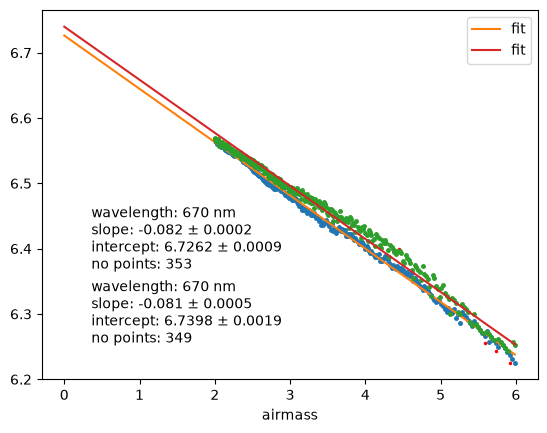

In [186]:
wl = 670
f,a = langc_am.plot(wavelength=wl, textpos=txtpos)
langc_pm.plot(wavelength= wl, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

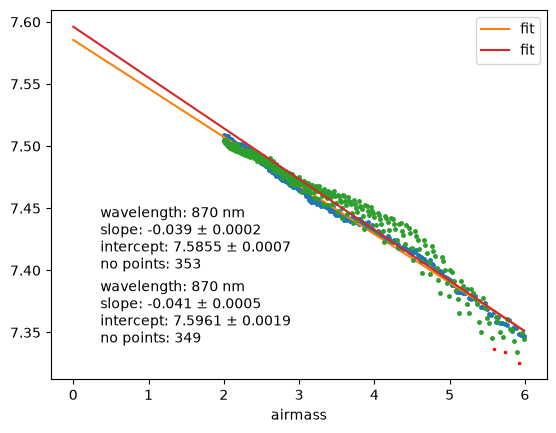

In [194]:
wl = 870
f,a = langc_am.plot(wavelength=wl, textpos=txtpos)
langc_pm.plot(wavelength= wl, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

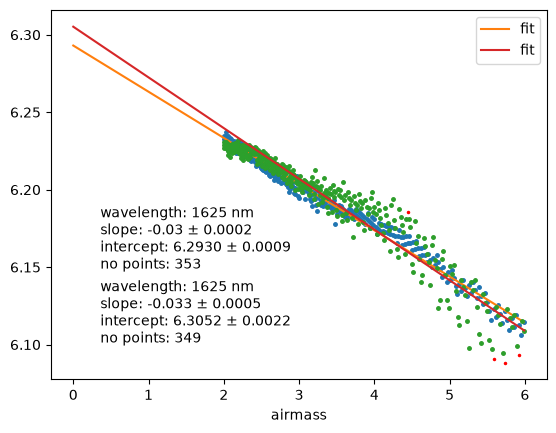

In [188]:
wl = 1625
f,a = langc_am.plot(wavelength=wl, textpos=txtpos)
langc_pm.plot(wavelength= wl, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

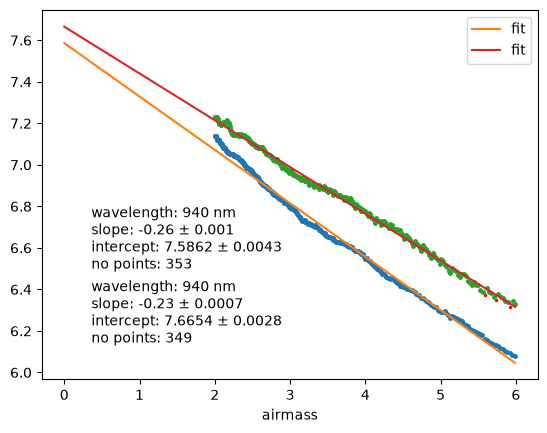

In [189]:
wl = 940
f,a = langc_am.plot(wavelength=wl, textpos=txtpos)
langc_pm.plot(wavelength= wl, ax = a)

# NEXT: continue the above (helper function line ~ ?)

In [ ]:
# get ozone
path2geosfp = pl.Path('/Volumes/stu3data2/Model_data/geos_fp/tavg1_2d_slv_Nx/surfrad/v0.1/')
p2fgeos = path2geosfp / f'{row.name.strftime("%Y")}' / f'surfrad_geosfp_tavg1_2d_slv_Nx_{row.name.strftime("%Y%m%d")}.nc'
assert(p2fgeos.exists()), f'geos_fp file (containing the ozone data) does not exist at {p2fgeos}'
ds_ozone = xr.open_dataset(p2fgeos) 

# Get the right pwd lookuptable

In [ ]:
fnlut = f'/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_{serialno}.nc'
p2fld_lang, fnlut

# Some databank stuff, might not be needed later?

In [45]:
import surfradpy.database as srfdb

In [54]:
reload(srfdb)

<module 'surfradpy.database' from '/Users/htelg/prog/SURFRAD/surfradpy/database.py'>

In [55]:
srfdb.get_default_db_path()

PosixPath('/Users/htelg/prog/SURFRAD/notebooks/databases/surfrad_database.db')

In [56]:
db = srfdb.SurfradDatabase(srfdb.get_default_db_path())

In [57]:
columns = ['id', 'lang_version','site', 'date', 'path2file', 'channel','V0']

In [58]:
db.add_table(tbl_name="mfrsr_calibration_parameters", columns=columns)

In [ ]:
db.